In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [36]:
df = pd.read_csv('Datasets\cumulative.csv', index_col='rowid')
# One hot labeling of categorical columns
df = pd.get_dummies(df,columns=['koi_disposition'], dtype=int)

df.head()

,kepid,kepoi_name,kepler_name,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,...,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,koi_disposition_CANDIDATE,koi_disposition_CONFIRMED,koi_disposition_FALSE POSITIVE
rowid,,,,,,,,,,,,,,,,,,,,,
1,10797460,K00752.01,Kepler-227 b,CANDIDATE,1.000,0,0,0,0,9.488036,...,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,0,1,0
2,10797460,K00752.02,Kepler-227 c,CANDIDATE,0.969,0,0,0,0,54.418383,...,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,0,1,0
3,10811496,K00753.01,NaN,FALSE POSITIVE,0.000,0,1,0,0,19.899140,...,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,0,0,1
4,10848459,K00754.01,NaN,FALSE POSITIVE,0.000,0,1,0,0,1.736952,...,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,0,0,1
5,10854555,K00755.01,Kepler-664 b,CANDIDATE,1.000,0,0,0,0,2.525592,...,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,0,1,0


**Extracting Data**

In [37]:
columns_to_drop =[
        'kepler_name','koi_score','koi_period_err1','koi_period_err2','koi_time0bk_err1','koi_time0bk_err2',
        'koi_impact_err1','koi_impact_err2','koi_duration_err1','koi_duration_err2','koi_depth_err1','koi_depth_err2',
        'koi_prad_err1','koi_prad_err2','koi_teq_err1','koi_teq_err2','koi_insol_err1','koi_insol_err2',
        'koi_steff_err1','koi_steff_err2','koi_slogg_err1','koi_slogg_err2','koi_srad_err1','koi_srad_err2','koi_pdisposition'
]

In [50]:
data_extracted = df.drop(columns=columns_to_drop)
data_extracted.head()

,kepid,kepoi_name,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,...,koi_tce_delivname,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_disposition_CANDIDATE,koi_disposition_CONFIRMED,koi_disposition_FALSE POSITIVE
rowid,,,,,,,,,,,,,,,,,,,,,
1,10797460,K00752.01,0,0,0,0,9.488036,170.538750,0.146,2.95750,...,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,1,0
2,10797460,K00752.02,0,0,0,0,54.418383,162.513840,0.586,4.50700,...,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,1,0
3,10811496,K00753.01,0,1,0,0,19.899140,175.850252,0.969,1.78220,...,q1_q17_dr25_tce,5853.0,4.544,0.868,297.00482,48.134129,15.436,0,0,1
4,10848459,K00754.01,0,1,0,0,1.736952,170.307565,1.276,2.40641,...,q1_q17_dr25_tce,5805.0,4.564,0.791,285.53461,48.285210,15.597,0,0,1
5,10854555,K00755.01,0,0,0,0,2.525592,171.595550,0.701,1.65450,...,q1_q17_dr25_tce,6031.0,4.438,1.046,288.75488,48.226200,15.509,0,1,0


In [42]:
print(data_extracted.columns.tolist())

['kepid', 'kepoi_name', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_steff', 'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag', 'koi_disposition_CANDIDATE', 'koi_disposition_CONFIRMED', 'koi_disposition_FALSE POSITIVE']


In [28]:
selected_cols = [
    'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co','koi_fpflag_ec', 'koi_period','koi_time0bk','koi_impact','koi_duration','koi_depth','koi_prad','koi_teq','koi_insol', 'koi_model_snr', 'koi_tce_plnt_num','koi_steff', 'koi_slogg','koi_srad','ra', 'dec', 'koi_kepmag', 'koi_disposition_CANDIDATE',
 'koi_disposition_CONFIRMED', 'koi_disposition_FALSE POSITIVE','koi_pdisposition_CANDIDATE',
 'koi_pdisposition_FALSE POSITIVE']

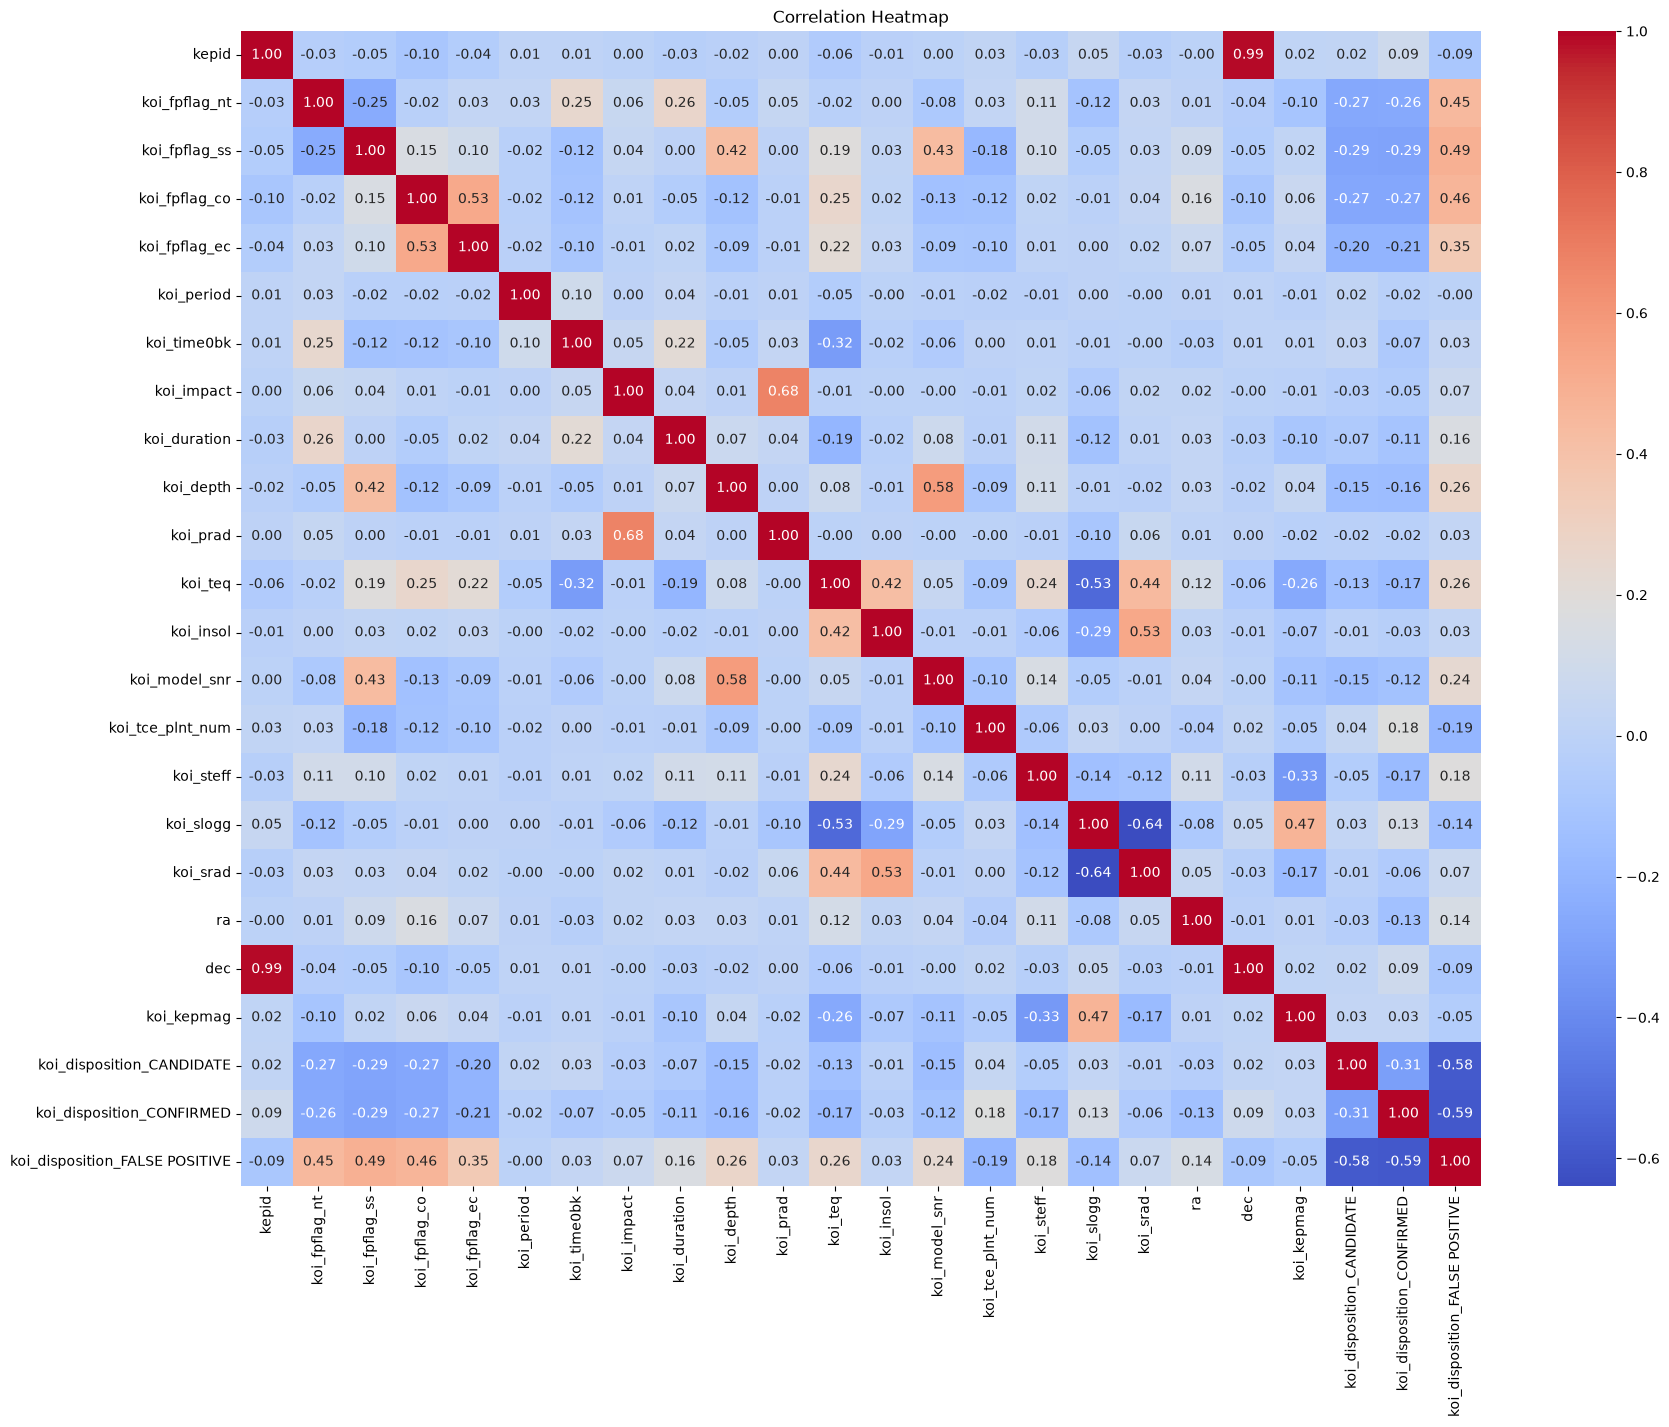

In [43]:
plt.figure(figsize=(20,15))

sns.heatmap(
    data_extracted.corr(numeric_only = True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [51]:
data_extracted.drop(columns=['kepoi_name','kepid' ,'koi_period', 'koi_time0bk', 'koi_impact', 'koi_prad', 'koi_insol', 'ra', 'dec', 'koi_kepmag'], inplace=True)

In [52]:
data_extracted.isnull().sum()

koi_fpflag_nt                       0
koi_fpflag_ss                       0
koi_fpflag_co                       0
koi_fpflag_ec                       0
koi_duration                        0
koi_depth                         363
koi_teq                           363
koi_model_snr                     363
koi_tce_plnt_num                  346
koi_tce_delivname                 346
koi_steff                         363
koi_slogg                         363
koi_srad                          363
koi_disposition_CANDIDATE           0
koi_disposition_CONFIRMED           0
koi_disposition_FALSE POSITIVE      0
dtype: int64

In [61]:
data_extracted.dropna(inplace=True)

In [64]:
data_extracted.isnull().sum()

koi_fpflag_nt                     0
koi_fpflag_ss                     0
koi_fpflag_co                     0
koi_fpflag_ec                     0
koi_duration                      0
koi_depth                         0
koi_teq                           0
koi_model_snr                     0
koi_tce_plnt_num                  0
koi_tce_delivname                 0
koi_steff                         0
koi_slogg                         0
koi_srad                          0
koi_disposition_CANDIDATE         0
koi_disposition_CONFIRMED         0
koi_disposition_FALSE POSITIVE    0
dtype: int64

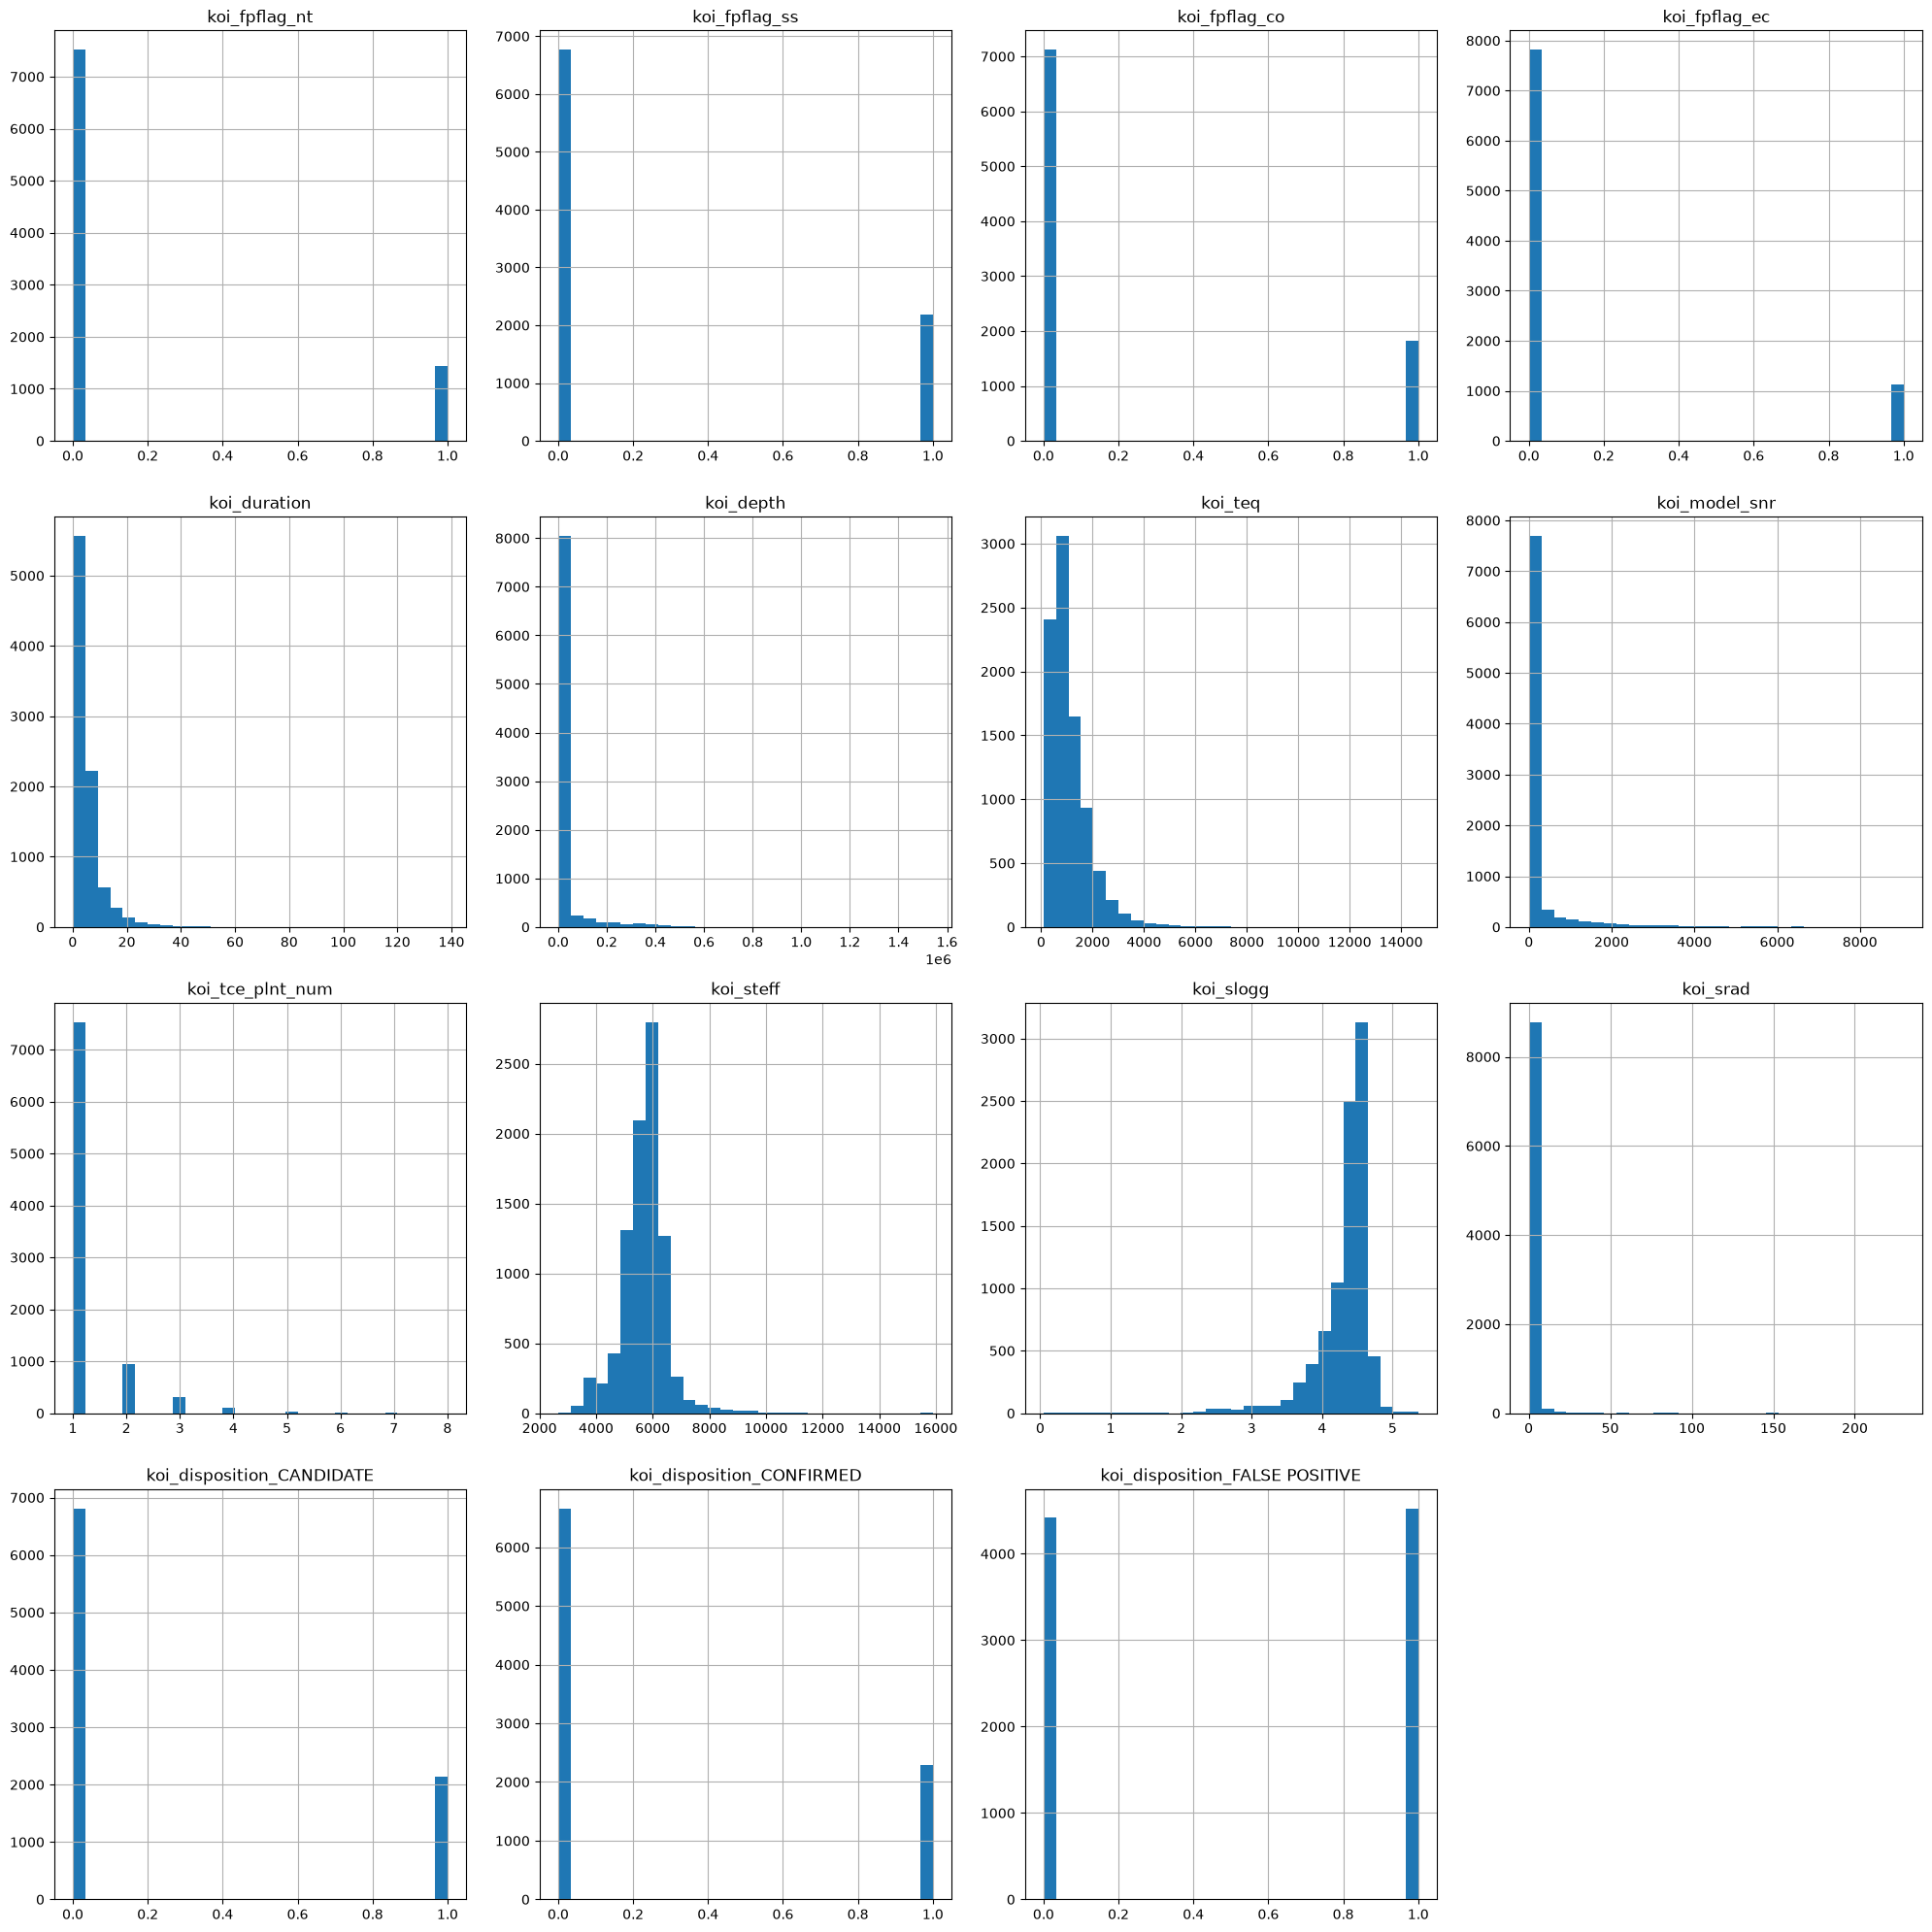

In [65]:
data_extracted.hist(figsize=(20, 20), bins=30)

plt.tight_layout()
plt.show()

In [68]:
data_extracted.to_csv('Datasets\cumulative_cleaned.csv', index=False)